#  CNN Fashion MNIST

* 본 파일은 GPU 런타임으로 연결됩니다.
* 경우에 따라서는 GPU 연결이 원활하지 않을 수도 있습니다.

## 1.환경준비

### (1) 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Input
from keras.backend import clear_session
from keras.optimizers import Adam
from keras.datasets import mnist, fashion_mnist

* 함수 만들기

In [2]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err')
    plt.plot(history['val_loss'], label='val_err')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (2) 데이터로딩

![fashion class](https://user-images.githubusercontent.com/60168331/117663987-35e42e00-b1dc-11eb-88c7-64db3b4fbff0.png)

In [3]:
# 케라스 데이터셋으로 부터 fashion_mnist 불러오기
(x_train, y_train), (x_val, y_val) = fashion_mnist.load_data()

In [4]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## 2 데이터 살펴보기

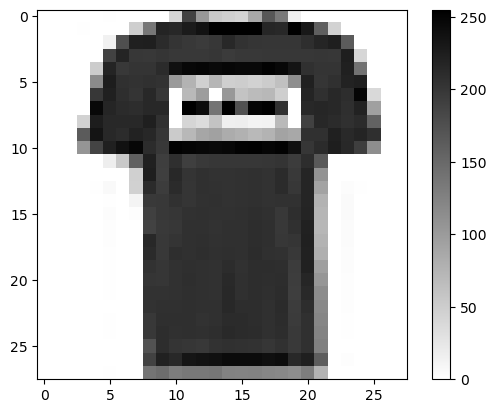

In [6]:
# 아래 숫자를 바꿔가며 화면에 그려 봅시다.
n = 1

plt.figure()
plt.imshow(x_train[n], cmap=plt.cm.binary)
plt.colorbar()
plt.show()

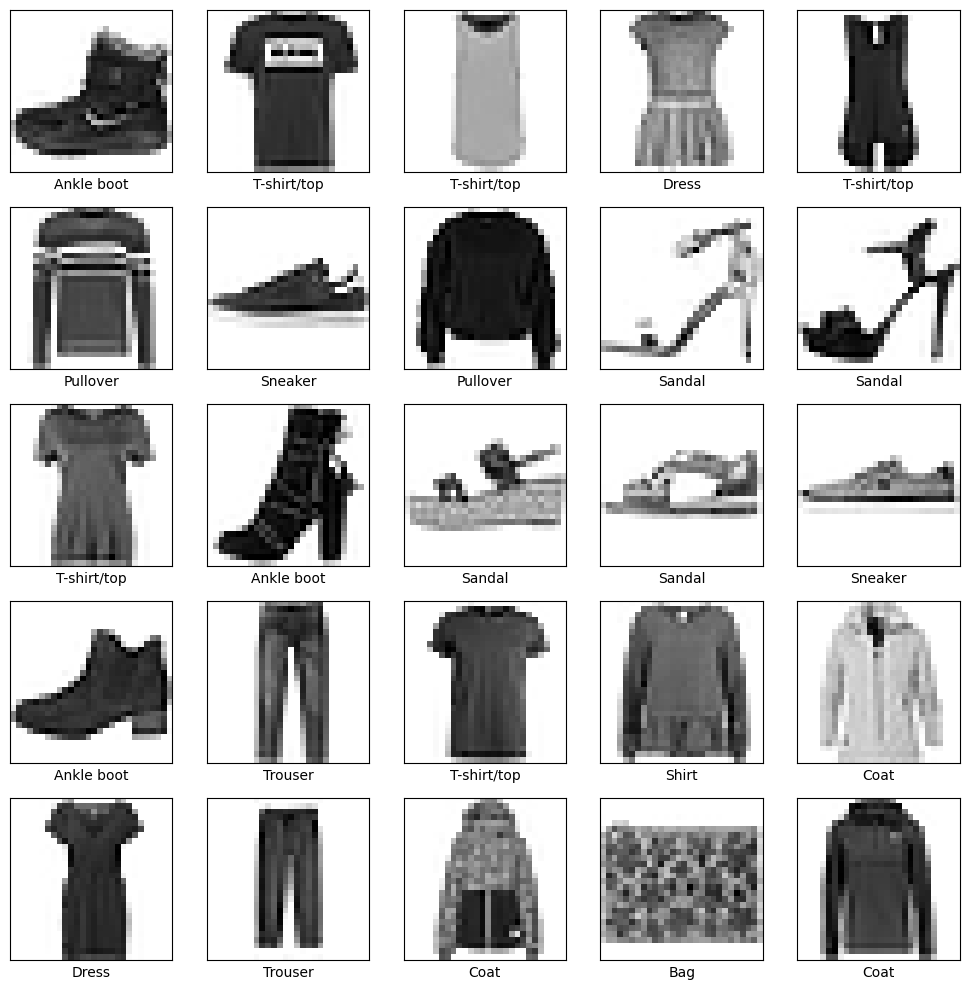

In [7]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.tight_layout()
plt.show()

## 3.데이터 준비

* CNN은 3차원 구조의 이미지(데이터셋은 4차원)를 입력해야 합니다.(input_shape)

In [8]:
x_train.shape, x_val.shape

((60000, 28, 28), (10000, 28, 28))

* reshape를 이용하여 다음과 같이 변환해 봅시다.
    * x_train.shape : (60000, 28, 28, 1)
    * x_val.shape : (10000, 28, 28, 1)

In [9]:
x_train = x_train.reshape(60000,28,28,1)
x_val = x_val.reshape(10000,28,28,1)

* Scaling : Min-Max
    * 0-255 값으로 되어 있는 데이터를 0-1사이 값으로 변환
    * x_train, x_test를 그냥 255로 나누면 됨

In [10]:
x_train = x_train / 255.
x_val = x_val / 255.

## 4.CNN 모델링

* 아래 그림의 구조대로 모델을 설계하고 학습해 봅시다.
* learning_rate = 0.0001

![](https://github.com/DA4BAM/image/blob/main/cnn_mnist3.png?raw=true)

In [11]:
clear_session()

model = Sequential([Input(shape = (28, 28, 1)),
                    Conv2D(32, kernel_size = 3, padding='same', activation='relu', strides=1),
                    MaxPooling2D(pool_size = 2 ,strides=2),             
					Conv2D(64, kernel_size = 3, padding='same', activation='relu', strides=1),
                    MaxPooling2D(pool_size = 2 ,strides=2),
                    Flatten(),
                    Dense(128, activation='relu'),
                    Dense(10, activation='softmax')
])

model.summary()

model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                                 
 dense (Dense)               (None, 128)               4

In [12]:
history = model.fit(x_train, y_train, epochs = 10, validation_split=0.2).history

Epoch 1/10
1500/1500 [==============================] - 12s 4ms/step - loss: 0.6326 - val_loss: 0.4486
Epoch 2/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4113 - val_loss: 0.3822
Epoch 3/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3692 - val_loss: 0.3630
Epoch 4/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3416 - val_loss: 0.3339
Epoch 5/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3187 - val_loss: 0.3259
Epoch 6/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3023 - val_loss: 0.3155
Epoch 7/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2891 - val_loss: 0.2996
Epoch 8/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2751 - val_loss: 0.2886
Epoch 9/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.2641 - val_loss: 0.2779
Epoch 10/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.25

* 학습결과 그래프

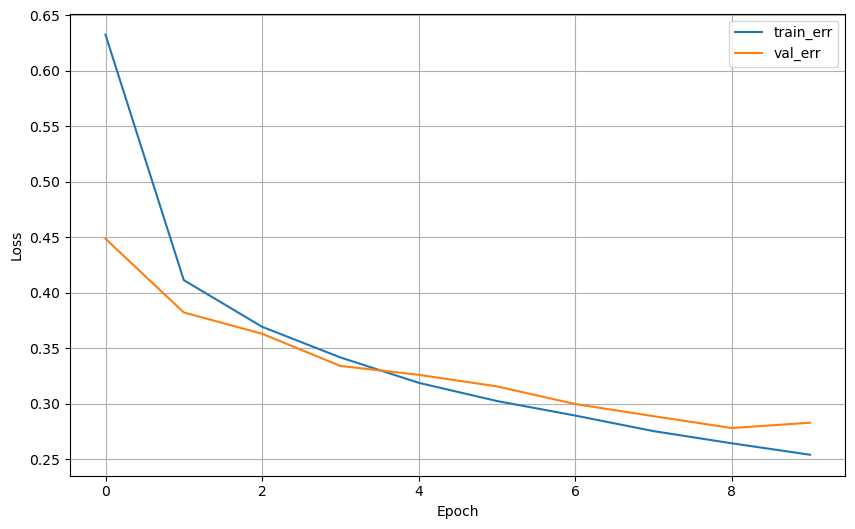

In [ ]:
dl_history_plot(history)

* 예측 및 평가

In [14]:
pred = model.predict(x_val)

313/313 [==============================] - 1s 1ms/step


In [ ]:
pred_1 = pred.argmax(axis=1)

In [ ]:
print(accuracy_score(y_val,pred_1))
print('-'*60)
print(confusion_matrix(y_val, pred_1))
print('-'*60)
print(classification_report(y_val, pred_1))

0.892
------------------------------------------------------------
[[908   0  14  16   1   1  50   0  10   0]
 [  2 977   0  13   2   0   4   0   2   0]
 [ 24   1 877  10  40   0  45   0   3   0]
 [ 33   2   9 920  10   0  23   0   3   0]
 [  4   2 106  57 725   0 104   0   2   0]
 [  0   0   0   1   0 978   0  15   1   5]
 [188   2  81  25  47   0 644   0  13   0]
 [  0   0   0   0   0  14   0 954   2  30]
 [  5   1   3   3   2   2   4   3 977   0]
 [  1   0   0   0   0   5   0  34   0 960]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.78      0.91      0.84      1000
           1       0.99      0.98      0.98      1000
           2       0.80      0.88      0.84      1000
           3       0.88      0.92      0.90      1000
           4       0.88      0.72      0.79      1000
           5       0.98      0.98      0.98      1000
           6       0.74      0.64      0.69      1000
        

In [24]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# 세션 초기화
clear_session()

# 🔹 모델 정의
model = Sequential([
    Input(shape=(28, 28, 1)),

    # Conv Block 1
    Conv2D(32, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=2, strides=2),
    Dropout(0.25),

    # Conv Block 2
    Conv2D(64, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=2, strides=2),
    Dropout(0.25),

    # Conv Block 3 (추가)
    Conv2D(128, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.summary()

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 28, 28, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 14, 14, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 14, 14, 64)       2

Epoch 1/20
1500/1500 [==============================] - 9s 6ms/step - loss: 0.5879 - accuracy: 0.7920 - val_loss: 0.3578 - val_accuracy: 0.8666
Epoch 2/20
1500/1500 [==============================] - 8s 5ms/step - loss: 0.4056 - accuracy: 0.8532 - val_loss: 0.3038 - val_accuracy: 0.8883
Epoch 3/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3492 - accuracy: 0.8744 - val_loss: 0.2809 - val_accuracy: 0.8997
Epoch 4/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.3189 - accuracy: 0.8861 - val_loss: 0.2525 - val_accuracy: 0.9082
Epoch 5/20
1500/1500 [==============================] - 8s 5ms/step - loss: 0.2964 - accuracy: 0.8921 - val_loss: 0.2681 - val_accuracy: 0.9002
Epoch 6/20
1500/1500 [==============================] - 8s 5ms/step - loss: 0.2774 - accuracy: 0.8991 - val_loss: 0.2449 - val_accuracy: 0.9139
Epoch 7/20
1500/1500 [==============================] - 7s 5ms/step - loss: 0.2659 - accuracy: 0.9047 - val_loss: 0.2492 - val_accuracy:

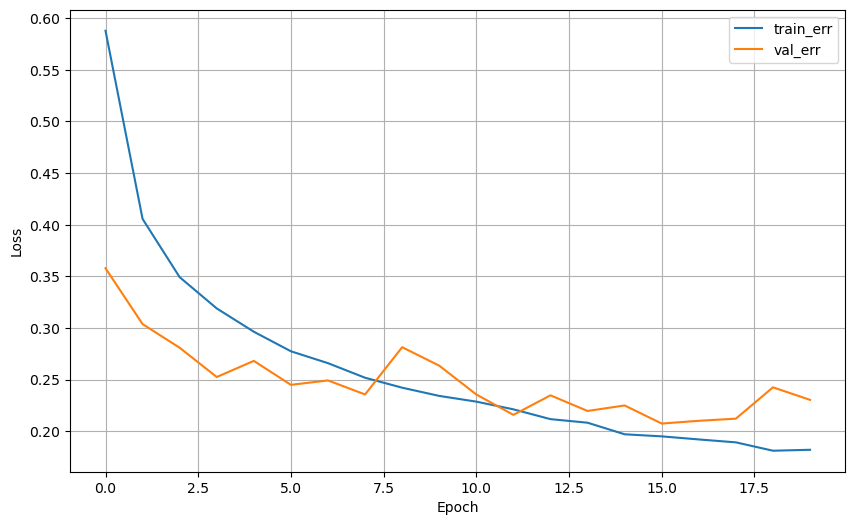

In [25]:
history = model.fit(x_train, y_train, epochs = 20, validation_split=0.2).history
dl_history_plot(history)

In [28]:
pred = model.predict(x_val)
pred_1 = pred.argmax(axis=1)
print(accuracy_score(y_val,pred_1))
print('-'*60)
print(confusion_matrix(y_val, pred_1))
print('-'*60)
print(classification_report(y_val, pred_1, target_names=class_names))

313/313 [==============================] - 1s 2ms/step
0.9226
------------------------------------------------------------
[[870   0  14  10   4   1 100   0   1   0]
 [  1 984   0  10   1   0   2   0   2   0]
 [ 17   1 837   5  69   0  71   0   0   0]
 [  8   3   7 939  15   0  27   0   1   0]
 [  0   0  15  29 885   0  71   0   0   0]
 [  0   0   0   0   0 988   0  12   0   0]
 [ 84   1  36  25  44   0 807   0   3   0]
 [  0   0   0   0   0   2   0 978   0  20]
 [  3   1   0   4   2   1   5   2 980   2]
 [  0   0   0   0   0   7   1  34   0 958]]
------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.89      0.87      0.88      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.92      0.84      0.88      1000
       Dress       0.92      0.94      0.93      1000
        Coat       0.87      0.89      0.88      1000
      Sandal       0.99      0.99      0.99      1000
      

## 5.틀린그림 찾아보기
위 모델의 결과에서 틀린 그림을 살펴 봅시다.

In [17]:
idx = (y_val != pred_1)
x_val_wr = x_val[idx]
y_val_wr = y_val[idx]
pred_wr = pred_1[idx]

x_val_wr = x_val_wr.reshape(-1,28,28)
print(x_val_wr.shape)

(1080, 28, 28)


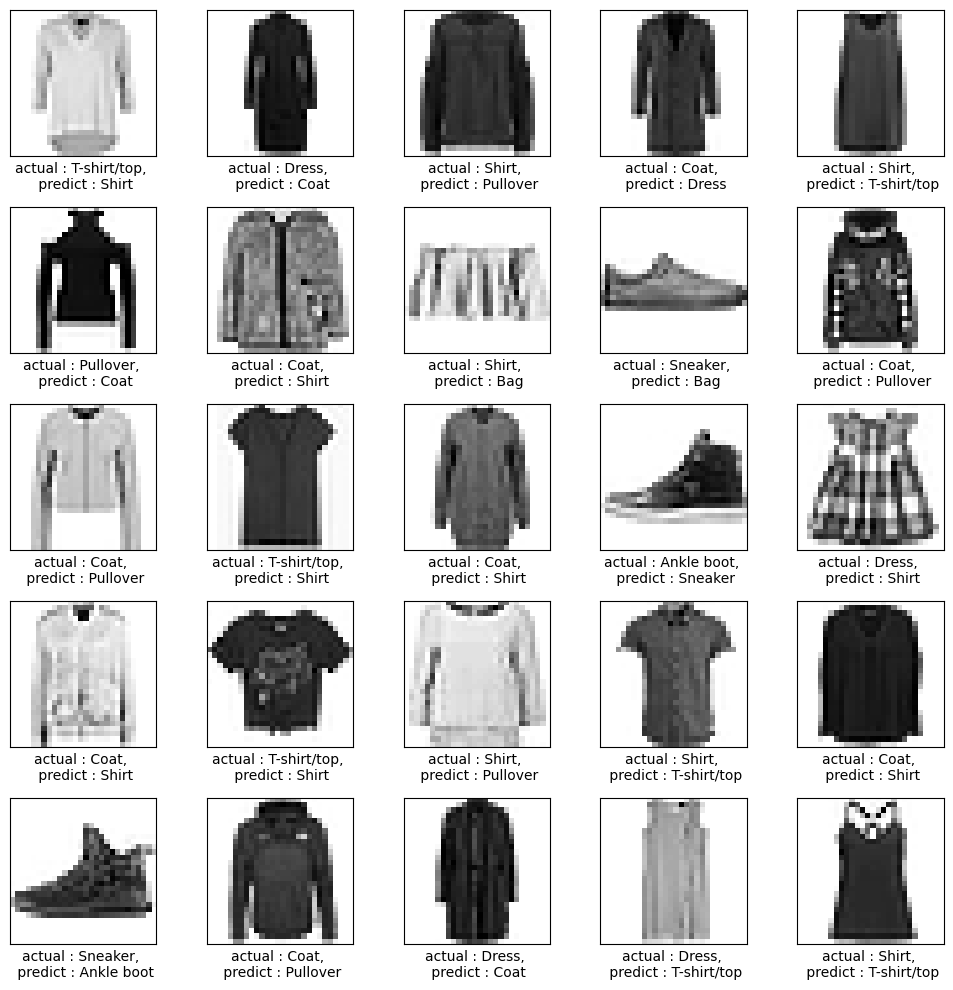

In [18]:
idx = rd.sample(range(x_val_wr.shape[0]),25)
x_temp = x_val_wr[idx]
y_temp = y_val_wr[idx]
p_temp = pred_wr[idx]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_temp[i], cmap=plt.cm.binary)
    plt.xlabel(f'actual : {class_names[y_temp[i]]}, \n predict : {class_names[p_temp[i]]}')
plt.tight_layout()
plt.show()

## 6.손으로 그린 그림으로 예측해 봅시다.

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

* 그림판에서 손으로 그린 그림을 업로드 합니다.

In [ ]:
# 다음 코드를 실행해서 파일을 업로드 합니다.
from google.colab import files
uploaded = files.upload()

In [ ]:
# 파일 열기 : 아래 파일 이름은 여러분의 파일로 수정합니다.
img = cv2.imread('f_t.png', cv2.IMREAD_GRAYSCALE)
cv2_imshow(img)
print(img.shape)

In [ ]:
# 크기 조절하기
img = cv2.resize(255-img, (28, 28))
print(img.shape)
cv2_imshow(img)

In [ ]:
test_num = img.reshape(1,28,28,1)
pred = model.predict(test_num)
pred_1 = pred.argmax(axis=1)
print(class_names[pred_1[0]])